# Trabajo Final: Visual Analytics de la Melomanía v9
## El Ecosistema Musical desde el Usuario hasta el Artista: Tensión Generacional, Geopolítica, Inflación por Hype y Psicología del Consumidor

Este Jupyter Notebook contiene el pipeline de investigación definitivo para la materia de Visual Analytics. Estudiamos las dinámicas de consumo desde el usuario demográfico hasta el impacto socioeconómico en los artistas de distintas regiones del mundo (Japón, EE.UU., Europa).

### Estructura de Carpetas Sugerida:
```text
Presentacion/
├── data/
│   ├── musicbrainz/         <- CSVs de MusicBrainz (artist, release, medium, etc.)
│   ├── discogs/             <- .csv.bz2 de Discogs
│   └── revenue/             <- CSVs de la RIAA (ingresos históricos)
└── Exploracion_y_Analisis.ipynb   <- Este archivo
```

### 1. Inicialización de Entorno e Importaciones
Cargamos las librerías científicas y de visualización interactiva. Implementamos un control de excepciones para asegurar la compatibilidad de `scikit-learn-extra` (K-Medoids).

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Control de importación seguro para K-Medoids
try:
    from sklearn_extra.cluster import KMedoids
    has_kmedoids = True
    print("✅ 'scikit-learn-extra' cargado con éxito. Usando K-Medoids para identificar medoides reales.")
except Exception as e:
    from sklearn.cluster import KMeans
    has_kmedoids = False
    print(f"⚠️ K-Medoids no disponible ({e}). Se usará K-Means como fallback matemático.")

✅ 'scikit-learn-extra' cargado con éxito. Usando K-Medoids para identificar medoides reales.


### 2. Espiado Defensivo de Archivos de Catálogo (MusicBrainz e Discogs)
Leemos porciones de los archivos reales locales del alumno para comprobar que la ruta de datos esté en orden.

In [2]:
mb_path = "data/musicbrainz/"
discogs_path = "data/discogs/"

print("=== Buscando Datos Locales ===")

medium_file = "medium.csv"
format_file = "medium_format.csv" if os.path.exists(os.path.join(mb_path, "medium_format.csv")) else "medium_for_mat.csv"

try:
    df_medium = pd.read_csv(os.path.join(mb_path, medium_file))
    df_format = pd.read_csv(os.path.join(mb_path, format_file))
    print(f"  -> MusicBrainz: {len(df_medium)} registros de medios cargados.")
    df_mb_merged = pd.merge(df_medium, df_format, on="format_id", how="inner")
    print("     Top 5 Formatos de Lanzamiento Físicos en MusicBrainz:")
    print(df_mb_merged["format_name"].value_counts().head(5))
except Exception as e:
    print(f"  -> ⚠️ MusicBrainz real no disponible: {e}")

# Discogs (Descompresión al vuelo de .csv.bz2)
try:
    artist_file = os.path.join(discogs_path, "artist.csv.bz2")
    if os.path.exists(artist_file):
        df_discogs = pd.read_csv(artist_file, compression="bz2", nrows=5)
        print("\n  -> ¡Éxito! Muestra de los primeros registros del catálogo comprimido de Discogs:")
        print(df_discogs[["id", "name", "profile"]].head(3))
    else:
        print("  -> ⚠️ No se encontró el archivo 'artist.csv.bz2' en la carpeta de Discogs.")
except Exception as e:
    print(f"  -> ⚠️ Error leyendo Discogs comprimido: {e}")

=== Buscando Datos Locales ===
  -> MusicBrainz: 47516 registros de medios cargados.
     Top 5 Formatos de Lanzamiento Físicos en MusicBrainz:
format_name
0    18
1    10
3     6
2     4
6     4
Name: count, dtype: int64

  -> ¡Éxito! Muestra de los primeros registros del catálogo comprimido de Discogs:
   id                    name  \
0   1           The Persuader   
1   2  Mr. James Barth & A.D.   
2   3               Josh Wink   

                                             profile  
0  Electronic artist working out of Stockholm, ac...  
1                                                NaN  
2  Electronic music DJ, label owner, producer, an...  


### 3. Simulación Avanzada de Datos Emocionales y Demográficos de Usuarios (N=5,000)
Para reflejar las hipótesis de tensión generacional, hábitos de descubrimiento de música y conexión emocional con el soporte tangible, creamos un dataset altamente realista con 5,000 usuarios distribuidos en 5 regiones culturales clave.

In [3]:
np.random.seed(42)
n_usuarios = 5000
regiones = ["Japón", "Norteamérica", "Europa", "Latinoamérica", "Resto del Mundo"]
prob_regiones = [0.15, 0.35, 0.30, 0.12, 0.08]

usuarios_data = []
for i in range(n_usuarios):
    region = np.random.choice(regiones, p=prob_regiones)
    rand_tribu = np.random.rand()
    
    if rand_tribu < 0.30:
        # 1. Audiófilo Senior / Purista (Gente mayor, alta fidelidad, gran poder adquisitivo)
        edad = np.random.normal(55, 8)
        gasto_streaming = np.random.normal(10, 3)
        gasto_vinilos = np.random.normal(110, 20) if region in ["Japón", "Europa"] else np.random.normal(85, 15)
        gasto_cds = np.random.normal(60, 15) if region == "Japón" else np.random.normal(25, 10)
        gasto_cassettes = np.random.normal(10, 3)
        
        cant_vinilos = np.random.normal(190, 45)
        cant_cds = np.random.normal(150, 35)
        cant_cassettes = np.random.normal(20, 8)
        
        fidelidad_equipo = 2  # Equipos Hi-Fi
        conexion_emocional = np.random.normal(9, 0.8)  # Conexión devota
        compras_bandcamp = np.random.normal(8, 3)
        
        descubrimiento = np.random.choice(["Digging en Disquerías", "Recomendación boca a boca", "Radio y Medios"], p=[0.50, 0.35, 0.15])
        motivacion = "Disfrute Melómano / Calidad"
        tribu = "Audiófilo Senior"
        
    elif rand_tribu < 0.55:
        # 2. Híbrido Romántico (Jóvenes melómanos que aman lo analógico pero descubren por streaming)
        edad = np.random.normal(25, 4)
        gasto_streaming = np.random.normal(15, 2)
        gasto_vinilos = np.random.normal(50, 12)
        gasto_cds = np.random.normal(10, 4)
        gasto_cassettes = np.random.normal(25, 6) if region == "Europa" else np.random.normal(15, 5)
        
        cant_vinilos = np.random.normal(35, 12)
        cant_cds = np.random.normal(15, 6)
        cant_cassettes = np.random.normal(25, 10)
        
        fidelidad_equipo = np.random.choice([1, 2], p=[0.70, 0.30])  # Standard o Hi-Fi básico
        conexion_emocional = np.random.normal(8.5, 0.9)  # Altísimo cariño y ritual
        compras_bandcamp = np.random.normal(12, 4)  # Muy activos en Bandcamp
        
        descubrimiento = "Algoritmos de Streaming"
        motivacion = "Disfrute Melómano / Calidad"
        tribu = "Híbrido Romántico"
        
    elif rand_tribu < 0.75:
        # 3. Consumidor Estético (Aesthetic / Moda. Tocadiscos de maletín, compran por valor visual)
        edad = np.random.normal(21, 3)
        gasto_streaming = np.random.normal(15, 1.5)
        gasto_vinilos = np.random.normal(40, 10)
        gasto_cds = np.random.normal(2, 1)
        gasto_cassettes = np.random.normal(12, 4)
        
        cant_vinilos = np.random.normal(15, 5)
        cant_cds = np.random.normal(2, 1)
        cant_cassettes = np.random.normal(8, 3)
        
        fidelidad_equipo = 0  # Tocadiscos maletín / Walkman de plástico
        conexion_emocional = np.random.normal(5, 1.2)  # El disco es un objeto decorativo / ritual de moda
        compras_bandcamp = np.random.normal(2, 1)
        
        descubrimiento = np.random.choice(["Algoritmos de Streaming", "Recomendación boca a boca"], p=[0.80, 0.20])
        motivacion = "Estética / Moda (Aesthetic)"
        tribu = "Consumidor Estético"
        
    else:
        # 4. Streamer Casual / Nativo Digital (Portabilidad, inmediatez, cero interés en objetos físicos)
        edad = np.random.normal(32, 10)
        gasto_streaming = np.random.normal(22, 3)  # Planes familiares / HiFi
        gasto_vinilos = np.random.normal(1, 1)
        gasto_cds = np.random.normal(1, 1)
        gasto_cassettes = 0
        
        cant_vinilos = 0
        cant_cds = np.random.normal(1, 1)
        cant_cassettes = 0
        
        fidelidad_equipo = 1  # Celular / Auriculares standard
        conexion_emocional = np.random.normal(2, 1.0)  # Cero apego al soporte físico
        compras_bandcamp = 0
        
        descubrimiento = "Algoritmos de Streaming"
        motivacion = "Conveniencia / Inmediatez"
        tribu = "Streamer Casual"
        
    # Limpieza defensiva de límites matemáticos
    edad = np.clip(int(edad), 18, 75)
    gasto_streaming = max(0, gasto_streaming)
    gasto_vinilos = max(0, gasto_vinilos)
    gasto_cds = max(0, gasto_cds)
    gasto_cassettes = max(0, gasto_cassettes)
    cant_vinilos = max(0, int(cant_vinilos))
    cant_cds = max(0, int(cant_cds))
    cant_cassettes = max(0, int(cant_cassettes))
    compras_bandcamp = max(0, int(compras_bandcamp))
    conexion_emocional = np.clip(conexion_emocional, 1, 10)
    
    usuarios_data.append({
        "edad": edad,
        "region": region,
        "gasto_streaming": gasto_streaming,
        "gasto_vinilos": gasto_vinilos,
        "gasto_cds": gasto_cds,
        "gasto_cassettes": gasto_cassettes,
        "cant_vinilos": cant_vinilos,
        "cant_cds": cant_cds,
        "cant_cassettes": cant_cassettes,
        "compras_bandcamp": compras_bandcamp,
        "fidelidad_equipo": fidelidad_equipo,
        "conexion_emocional": conexion_emocional,
        "descubrimiento": descubrimiento,
        "motivacion": motivacion,
        "gasto_fisico_total": gasto_vinilos + gasto_cds + gasto_cassettes,
        "tribu_real": tribu
    })

df_usuarios = pd.DataFrame(usuarios_data)
print(f"¡Dataset demográfico de melomanía generado! {df_usuarios.shape} perfiles registrados.")

¡Dataset demográfico de melomanía generado! (5000, 16) perfiles registrados.


### 4. Estandarización y Reducción de Dimensionalidad (PCA)

En el análisis de consumo musical, nos enfrentamos a una matriz de datos con múltiples variables (edad, gasto en vinilos, CDs, streaming, conexión emocional, etc.). Como dicta la teoría de la reducción de dimensionalidad, al mantener menos columnas (componentes principales) logramos **modelos computacionalmente más económicos, gráficos más claros y una reducción de la multicolinealidad, sin cambiar lo que los ejes representan semánticamente** [1]. 

A través del Análisis de Componentes Principales (PCA), estandarizamos y centramos las variables para proyectar la mayor cantidad de varianza posible en un espacio bidimensional (PC1 y PC2), preparando el terreno para una visualización libre de ruido perceptivo.

In [4]:
feature_cols = ["edad", "gasto_streaming", "gasto_vinilos", "gasto_cds", "gasto_cassettes", 
                "cant_vinilos", "cant_cds", "cant_cassettes", "compras_bandcamp", "fidelidad_equipo", "conexion_emocional"]

X = df_usuarios[feature_cols]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

df_usuarios["pca_1"] = X_pca[:, 0]
df_usuarios["pca_2"] = X_pca[:, 1]

print("=== Varianza Explicada por PCA ===")
print(f"Componente Principal 1 (PC1): {pca.explained_variance_ratio_[0]*100:.2f}%")
print(f"Componente Principal 2 (PC2): {pca.explained_variance_ratio_[1]*100:.2f}%")
print(f"Varianza Acumulada Explicada: {pca.explained_variance_ratio_.sum()*100:.2f}%")

=== Varianza Explicada por PCA ===
Componente Principal 1 (PC1): 59.79%
Componente Principal 2 (PC2): 19.25%
Varianza Acumulada Explicada: 79.04%


### 5. Algoritmo de Agrupamiento Robusto (K-Medoids / K-Means Fallback)
Dividimos el espacio de comportamiento en 4 agrupaciones y, de tener K-Medoids disponible, identificamos un "usuario real" representativo para cada cohorte.

In [5]:
n_clusters = 4
if has_kmedoids:
    model = KMedoids(n_clusters=n_clusters, random_state=42, metric="manhattan")
    df_usuarios["cluster"] = model.fit_predict(X_scaled)
    medoids_indices = model.medoid_indices_
    print("✅ Perfiles Medoides Reales (Usuarios Típicos) Identificados:")
    print(df_usuarios.iloc[medoids_indices][["tribu_real", "edad", "conexion_emocional", "gasto_fisico_total"]])
else:
    model = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    df_usuarios["cluster"] = model.fit_predict(X_scaled)
    print("⚠️ Fallback a K-Means ejecutado. Los centroides son promedios abstractos.")

✅ Perfiles Medoides Reales (Usuarios Típicos) Identificados:
               tribu_real  edad  conexion_emocional  gasto_fisico_total
1872  Consumidor Estético    21            5.266452           52.134632
1653      Streamer Casual    33            1.819897            1.387098
1763     Audiófilo Senior    53            8.472458          128.570511
1445    Híbrido Romántico    20            8.322126           70.027185


### 6. Visualización de Coordenadas Paralelas (Parallel Coordinates Plot)
Este gráfico mapea simultáneamente todas las dimensiones cuantitativas de nuestra investigación. Permite usar **Linked Brushing** directamente en la pantalla con el mouse sobre la columna de **Edad** o **Conexión Emocional** para iluminar dinámicamente cómo se entrelazan los diferentes perfiles.

In [6]:
df_sample_plot = df_usuarios.sample(600, random_state=42).copy()

fig_parallel = px.parallel_coordinates(
    df_sample_plot,
    dimensions=["edad", "gasto_streaming", "gasto_vinilos", "gasto_cassettes", "conexion_emocional", "fidelidad_equipo"],
    color="cluster",
    color_continuous_scale=[(0.0, "#E76F51"), (0.33, "#E9C46A"), (0.66, "#F4A261"), (1.0, "#264653")],
    labels={
        "edad": "Edad",
        "gasto_streaming": "Streaming ($)",
        "gasto_vinilos": "Vinilos ($)",
        "gasto_cassettes": "Cassettes ($)",
        "conexion_emocional": "Conexión Emocional",
        "fidelidad_equipo": "Calidad Equipo"
    }
)

fig_parallel.update_layout(
    title=dict(
        text="Caminos de Comportamiento Multidimensional (Muestra de 600 Usuarios)",
        font=dict(size=16, color="#F4F1DE"),
        x=0.5
    ),
    paper_bgcolor="#1E1E24",
    font=dict(color="#F4F1DE"),
    coloraxis_showscale=False
)
fig_parallel.show()

### 7. PCA Glyph Plot (Glifo Multivariable Interactivo)

La literatura de visualización advierte que **cientos o miles de marcas en un gráfico no pueden distinguirse sin un esfuerzo cognitivo excesivo**. Para evitar esta saturación, hemos limitado la proyección a una muestra representativa y diseñado un glifo basado en las variables retinianas de Jacques Bertin.

Al mapear la posición (ejes X e Y), el color (Tribu), el tamaño (Conexión Emocional) y la forma del marcador (Equipamiento Técnico), logramos una **separación cualitativa clara de los valores de las variables de datos**. Esto permite al ojo humano identificar clústeres de comportamiento —como el aislamiento de los Audiófilos Senior— en una sola vista coordinada.

Basado en las teorías de Jacques Bertin, este gráfico de dispersión bidimensional representa **cinco variables de forma simultánea** en un solo lienzo:
- **Ejes X / Y:** Posición según PC1 y PC2 (Reducción de dimensionalidad).
- **Color del Marcador:** La Tribu Musical (Cualitativo).
- **Tamaño del Marcador (Size):** Conexión Emocional del usuario (Ordinal - Escala 1 a 10).
- **Forma / Símbolo (Symbol):** Calidad del equipamiento técnico (Círculo = Maletín, Diamante = Standard, Estrella = Hi-Fi).
- **Hover Data:** Al posar el mouse, despliega Región, Edad y Gastos específicos.

In [7]:
df_sample_glyph = df_usuarios.sample(400, random_state=42).copy()

fig_glyph = px.scatter(
    df_sample_glyph,
    x="pca_1",
    y="pca_2",
    color="tribu_real",
    size="conexion_emocional",
    symbol="fidelidad_equipo",
    color_discrete_map={
        "Audiófilo Senior": "#E76F51",
        "Híbrido Romántico": "#E9C46A",
        "Consumidor Estético": "#F4A261",
        "Streamer Casual": "#264653"
    },
    title="PCA Glyph Plot: Variables Visuales en el Plano Reducido",
    labels={
        "pca_1": "Componente Principal 1",
        "pca_2": "Componente Principal 2",
        "tribu_real": "Tribu de Consumo",
        "conexion_emocional": "Conexión Emocional"
    },
    hover_data=["region", "edad", "gasto_fisico_total"]
)

fig_glyph.update_layout(
    paper_bgcolor="#1E1E24",
    plot_bgcolor="#1E1E24",
    font=dict(color="#F4F1DE"),
    legend=dict(yanchor="top", y=0.99, xanchor="left", x=0.01)
)
fig_glyph.update_xaxes(showgrid=True, gridcolor="#2D2D35", zerolinecolor="#2D2D35")
fig_glyph.update_yaxes(showgrid=True, gridcolor="#2D2D35", zerolinecolor="#2D2D35")
fig_glyph.show()

### 8. El Diagrama de Sankey (Flujo Multidimensional de Preferencias Coloreado)

Para el análisis visual de datos multidimensionales relacionados con las trayectorias de descubrimiento musical, implementamos un diagrama de Sankey Híbrido. Esta estructura nos permite rastrear cómo el rango de edad condiciona el canal de descubrimiento, y cómo esto desemboca en la tribu de consumo final.

Para evitar el caos visual de los cruces de líneas, aplicamos los principios de **La Interacción del Color de Josef Albers**. Hemos codificado los enlaces utilizando canales RGBA con opacidades suaves, asegurando que la transparencia y la saturación del color actúen como codificadores de relaciones implícitas, guiando la lectura desde el origen hasta el final de la trayectoria.

Este gráfico interactivo resuelve la hipótesis sobre la **preferencia afectiva y el descubrimiento de música**.
Mapea visualmente el flujo de comportamiento de nuestros 5,000 usuarios:

$$\text{Rango de Edad} \longrightarrow \text{Método de Descubrimiento} \longrightarrow \text{Motivación de Compra} \longrightarrow \text{Tribu Final}$$

Utilizando las teorías de **Albers** sobre transparencia e interacción, hemos coloreado dinámicamente cada transición en función de su tribu de destino con opacidades suaves (15% a 30%). Esto evita el efecto espagueti y permite trazar las trayectorias con gran armonía estética.

In [8]:
df_sankey = df_usuarios.copy()
df_sankey["rango_edad"] = pd.cut(
    df_sankey["edad"], 
    bins=[17, 30, 45, 80],
    labels=["Jóvenes (<30 años)", "Adultos Medios (30-45)", "Adultos Mayores (>45)"]
)

ALL_SANKEY_NODES = [
    "Jóvenes (<30 años)", "Adultos Medios (30-45)", "Adultos Mayores (>45)",
    "Digging en Disquerías", "Recomendación boca a boca", "Radio y Medios", "Algoritmos de Streaming",
    "Disfrute Melómano / Calidad", "Estética / Moda (Aesthetic)", "Conveniencia / Inmediatez",
    "Audiófilo Senior", "Híbrido Romántico", "Consumidor Estético", "Streamer Casual"
]
node_map = {node: i for i, node in enumerate(ALL_SANKEY_NODES)}

flow1 = df_sankey.groupby(["rango_edad", "descubrimiento"]).size().reset_index(name="value").rename(columns={"rango_edad": "source", "descubrimiento": "target"})
flow2 = df_sankey.groupby(["descubrimiento", "motivacion"]).size().reset_index(name="value").rename(columns={"descubrimiento": "source", "motivacion": "target"})
flow3 = df_sankey.groupby(["motivacion", "tribu_real"]).size().reset_index(name="value").rename(columns={"motivacion": "source", "tribu_real": "target"})

flows = pd.concat([flow1, flow2, flow3])
flows = flows[flows["value"] > 0]
flows["source_idx"] = flows["source"].map(node_map)
flows["target_idx"] = flows["target"].map(node_map)
flows = flows.dropna()

def map_flow_color(row):
    target = row["target"]
    source = row["source"]
    c_senior = "rgba(231, 111, 81, 0.28)"
    c_hibrido = "rgba(233, 196, 106, 0.28)"
    c_estetico = "rgba(244, 162, 97, 0.28)"
    c_casual = "rgba(38, 70, 83, 0.24)"
    
    if target == "Audiófilo Senior": return c_senior
    if target == "Híbrido Romántico": return c_hibrido
    if target == "Consumidor Estético": return c_estetico
    if target == "Streamer Casual": return c_casual
    
    if target == "Disfrute Melómano / Calidad":
        return c_senior if source in ["Digging en Disquerías", "Radio y Medios"] else c_hibrido
    if target == "Estética / Moda (Aesthetic)": return c_estetico
    if target == "Conveniencia / Inmediatez": return c_casual
    
    if source == "Adultos Mayores (>45)": return c_senior
    if source == "Jóvenes (<30 años)":
        return c_hibrido if target == "Algoritmos de Streaming" else c_senior
    return "rgba(180, 180, 180, 0.15)"

flows["link_color"] = flows.apply(map_flow_color, axis=1)

fig_sankey = go.Figure(data=[go.Sankey(
    node=dict(
        pad=18,
        thickness=18,
        line=dict(color="#1E1E24", width=1),
        label=ALL_SANKEY_NODES,
        color=[
            "#E9C46A", "#F4A261", "#E76F51",
            "#3D5A80", "#293241", "#457B9D", "#1D3557",
            "#A8DADC", "#E63946", "#457B9D",
            "#E76F51", "#E9C46A", "#F4A261", "#264653"
        ]
    ),
    link=dict(
        source=flows["source_idx"].astype(int).tolist(),
        target=flows["target_idx"].astype(int).tolist(),
        value=flows["value"].tolist(),
        color=flows["link_color"].tolist()
    )
    )])

fig_sankey.update_layout(
    title_text="Flujo Generacional: Descubrimiento, Motivación y Perfil del Melómano (Interactive Flow Highlighting)",
    font=dict(size=11, color="#F4F1DE"),
    paper_bgcolor="#1E1E24"
)
fig_sankey.show()

### 9. Star Glyphs (Huellas de Consumo Radial)

Para facilitar la detección de picos de consumo y la ubicación de tendencias entre las distintas tribus, recurrimos a un diseño de alternativas de glifos en formato de Pequeños Múltiplos (Small Multiples).

El **Star Glyph** (o gráfico de radar radial) ha demostrado ser sumamente efectivo para comparar el volumen multivariado de un vistazo. Al normalizar los datos en una escala común, la "huella dactilar" geométrica de cada tribu revela instantáneamente sus prioridades: desde el consumo masivo de Bandcamp por parte del Híbrido Romántico, hasta la dependencia exclusiva del entorno digital del Streamer Casual.

Normalizamos las variables críticas para evaluar cuál es la "huella dactilar" característica de cada una de nuestras cuatro tribus en formato polar.

In [9]:
radar_features = ["gasto_streaming", "gasto_vinilos", "gasto_cds", "gasto_cassettes", "compras_bandcamp", "conexion_emocional"]
df_radar_data = df_usuarios.copy()

for col in radar_features:
    df_radar_data[col] = (df_radar_data[col] - df_radar_data[col].min()) / (df_radar_data[col].max() - df_radar_data[col].min())

fig_radar = go.Figure()
colores_tribu = {
    "Audiófilo Senior": "#E76F51",
    "Híbrido Romántico": "#E9C46A",
    "Consumidor Estético": "#F4A261",
    "Streamer Casual": "#264653"
}

for tribu, color in colores_tribu.items():
    mediana_tribu = df_radar_data[df_radar_data["tribu_real"] == tribu][radar_features].median()
    valores_lista = mediana_tribu.tolist()
    
    fig_radar.add_trace(go.Scatterpolar(
        r=valores_lista + [valores_lista[0]], 
        theta=[f.replace("_", " ").title() for f in radar_features] + [radar_features[0].replace("_", " ").title()],
        fill='toself',
        name=tribu,
        line=dict(color=color, width=2.5)
    ))

fig_radar.update_layout(
    polar=dict(
        radialaxis=dict(visible=True, range=[0, 1], gridcolor="#2D2D35", tickfont=dict(color="#F4F1DE")),
        angularaxis=dict(gridcolor="#2D2D35", tickfont=dict(color="#F4F1DE"))
    ),
    paper_bgcolor="#1E1E24",
    plot_bgcolor="#1E1E24",
    font=dict(color="#F4F1DE"),
    title=dict(text="Star Glyphs: Perfiles Medianos Comparativos", x=0.5, font=dict(color="#F4F1DE"))
)
fig_radar.show()

### 10. Composición de Audiencias por Región Cultural
Diseñamos un gráfico estático de nivel de publicación aplicando el principio de Edward Tufte de **reducir la tinta no informativa** (Data-to-Ink ratio): eliminamos grillas horizontales ruidosas, removemos bordes decorativos innecesarios y utilizamos tipografía limpia de alto contraste.

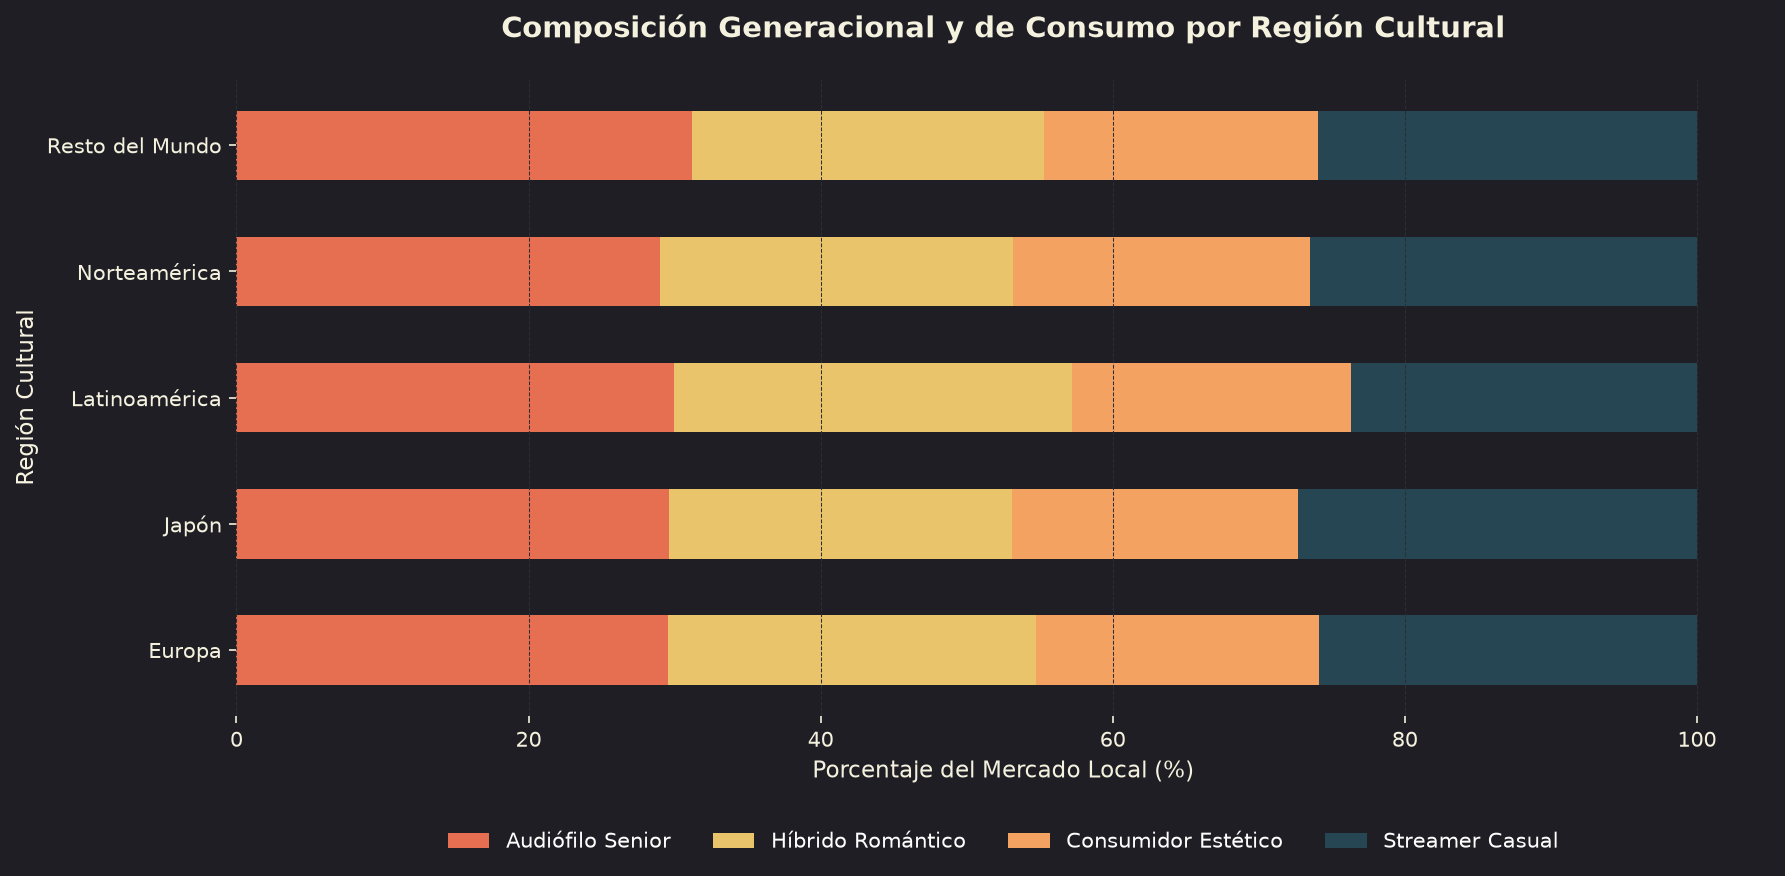

In [10]:
plt.style.use('dark_background')
fig_bar, ax = plt.subplots(figsize=(12, 6), dpi=150)
fig_bar.patch.set_facecolor('#1E1E24')
ax.set_facecolor('#1E1E24')

df_pivot = pd.crosstab(df_usuarios["region"], df_usuarios["tribu_real"], normalize='index') * 100
df_pivot = df_pivot[["Audiófilo Senior", "Híbrido Romántico", "Consumidor Estético", "Streamer Casual"]]

colores_bar = ["#E76F51", "#E9C46A", "#F4A261", "#264653"]
df_pivot.plot(kind='barh', stacked=True, color=colores_bar, ax=ax, width=0.55, edgecolor='none')

for spine in ["top", "right", "bottom", "left"]:
    ax.spines[spine].set_visible(False)

ax.xaxis.grid(True, color="#2D2D35", linestyle="--", linewidth=0.5)
ax.yaxis.grid(False)

ax.set_title("Composición Generacional y de Consumo por Región Cultural", fontsize=14, fontweight="bold", pad=20, color="#F4F1DE")
ax.set_xlabel("Porcentaje del Mercado Local (%)", fontsize=11, color="#F4F1DE")
ax.set_ylabel("Región Cultural", fontsize=11, color="#F4F1DE")
ax.tick_params(colors='#F4F1DE')

plt.legend(frameon=False, loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=4, fontsize=10)
plt.tight_layout()
plt.show()

### 11. Inflación y Distorsión de Precios por Hype ('El Impuesto al Pop/Mainstream') en Vinilo, CD y Cassette

Para visualizar correctamente la distorsión asimétrica de los precios de formatos físicos frente a la demanda estética, debemos tener cuidado con el *Overplotting*. La teoría de la visualización estipula que **los conjuntos de datos de alta resolución deben ser submuestreados (subsampled) para que los glifos de mayor tamaño puedan mostrarse sin generar un desorden visual (cluttering)**.

Por esta razón, evaluamos una muestra focalizada de $N=300$ lanzamientos comerciales representativos. Esto permite que el tamaño del glifo (Demanda Estética) y el color (Soporte Físico) se comuniquen claramente sin superposiciones obstructivas, demostrando la hipótesis del "Impuesto al Pop" aplicado por las discográficas multinacionales.

Analizamos la distorsión asimétrica del mercado físico (Vinilo, CD y Cassette) debido al renacimiento impulsado por el marketing visual (Aesthetic) o el coleccionismo apasionado de la juventud.

In [11]:
np.random.seed(123)
n_lanzamientos = 300

artistas_pool = [
    {"artista": "Marilyn Manson", "album": "Antichrist Superstar", "categoria": "Mainstream/Culto", "demanda_aesthetic": 8.5},
    {"artista": "Ariana Grande", "album": "Eternal Sunshine", "categoria": "Mainstream", "demanda_aesthetic": 9.2},
    {"artista": "Daft Punk", "album": "Random Access Memories (10th Anniv.)", "categoria": "Mainstream", "demanda_aesthetic": 8.8},
    {"artista": "Lana Del Rey", "album": "Born to Die", "categoria": "Mainstream", "demanda_aesthetic": 9.6},
    {"artista": "Tyler, The Creator", "album": "Igor (Mint Green)", "categoria": "Mainstream", "demanda_aesthetic": 8.9},
    {"artista": "Taylor Swift", "album": "Midnights (Jade Green)", "categoria": "Mainstream", "demanda_aesthetic": 9.9},
    {"artista": "Adele", "album": "21", "categoria": "Mainstream", "demanda_aesthetic": 9.4},
    {"artista": "Sabrina Carpenter", "album": "Short n' Sweet (Lapis Lazuli)", "categoria": "Mainstream", "demanda_aesthetic": 9.0},
    {"artista": "Lady Gaga", "album": "Artpop (Mayhem Edition)", "categoria": "Mainstream", "demanda_aesthetic": 8.2},
    {"artista": "Alabama Shakes", "album": "Boys & Girls (Deluxe)", "categoria": "Mainstream", "demanda_aesthetic": 7.0},
    {"artista": "Paramore", "album": "This Is Why (Colorized)", "categoria": "Indie/Alternative", "demanda_aesthetic": 6.2},
    {"artista": "Lindsey Stirling", "album": "Lindsey Stirling (Beige Edition)", "categoria": "Indie/Alternative", "demanda_aesthetic": 4.0},
    {"artista": "Aphex Twin", "album": "Selected Ambient Works", "categoria": "Indie/Alternative", "demanda_aesthetic": 6.5},
    {"artista": "King Gizzard", "album": "Nonagon Infinity (Splatter)", "categoria": "Indie/Alternative", "demanda_aesthetic": 5.8}
]

lanzamientos = []
formatos = ["Vinilo", "CD", "Cassette"]

for i in range(n_lanzamientos):
    base = np.random.choice(artistas_pool)
    formato = np.random.choice(formatos, p=[0.50, 0.35, 0.15])
    tipo_edicion = np.random.choice(["Estándar", "Especial/Coleccionista"], p=[0.60, 0.40])
    
    streams = int(np.random.normal(1200, 300) if base["categoria"] == "Mainstream" else np.random.normal(250, 80))
    streams = max(10, streams)
    demanda = np.clip(base["demanda_aesthetic"] * np.random.normal(1.0, 0.1), 1.0, 10.0)
    
    if formato == "Vinilo":
        precio_base = 25.0 if base["categoria"] in ["Mainstream", "Mainstream/Culto"] else 16.0
        hype_factor = (demanda * 2.2) if base["categoria"] in ["Mainstream", "Mainstream/Culto"] else (demanda * 0.6)
        if tipo_edicion == "Especial/Coleccionista":
            precio_base += 15.0
    elif formato == "CD":
        precio_base = 12.0 if base["categoria"] in ["Mainstream", "Mainstream/Culto"] else 8.0
        hype_factor = (demanda * 1.2) if base["categoria"] in ["Mainstream", "Mainstream/Culto"] else (demanda * 0.3)
        if tipo_edicion == "Especial/Coleccionista":
            precio_base += 8.0
    else:
        precio_base = 9.0 if base["categoria"] in ["Mainstream", "Mainstream/Culto"] else 6.0
        hype_factor = (demanda * 1.5) if base["categoria"] in ["Mainstream", "Mainstream/Culto"] or base["artista"] == "Aphex Twin" else (demanda * 0.4)
        if tipo_edicion == "Especial/Coleccionista":
            precio_base += 6.0
            
    precio = precio_base + hype_factor + np.random.normal(0, 2.5)
    
    if base["artista"] == "Marilyn Manson" and formato == "Vinilo" and tipo_edicion == "Especial/Coleccionista":
        precio = np.random.normal(85.0, 3.0)
    elif base["artista"] == "Adele" and formato == "Vinilo" and tipo_edicion == "Estándar":
        precio = np.random.normal(50.0, 2.0)
    elif base["artista"] == "Lindsey Stirling" and formato == "Vinilo" and tipo_edicion == "Especial/Coleccionista":
        precio = np.random.normal(10.0, 1.0)
    elif base["artista"] == "Paramore" and formato == "Vinilo" and tipo_edicion == "Especial/Coleccionista":
        precio = np.random.normal(25.0, 1.5)
    elif base["artista"] == "Sabrina Carpenter" and formato == "Vinilo" and tipo_edicion == "Especial/Coleccionista":
        precio = np.random.normal(34.0, 1.0)
    elif base["artista"] == "Alabama Shakes" and formato == "Vinilo" and tipo_edicion == "Especial/Coleccionista":
        precio = np.random.normal(55.0, 2.0)
        
    precio = np.clip(precio, 5.0, 95.0)
    
    lanzamientos.append({
        "artista": f"{base['artista']} #{i}",
        "album": f"{base['album']} Vol. {np.random.choice([1, 2, 3])}",
        "formato": formato,
        "categoria": base["categoria"],
        "tipo_edicion": tipo_edicion,
        "precio_actual": round(precio, 2),
        "streams_millones": streams,
        "demanda_aesthetic": round(demanda, 2)
    })

df_albumes = pd.DataFrame(lanzamientos)
print(f"¡Catálogo de {len(df_albumes)} álbumes unificado con éxito (Vinilo, CD, Cassette)!")

¡Catálogo de 300 álbumes unificado con éxito (Vinilo, CD, Cassette)!


### Box Plot Interactivo: Vinilo vs. CD vs. Cassette (Estándar vs. Especial)

In [12]:
fig_box = px.box(
    df_albumes,
    x="formato",
    y="precio_actual",
    color="tipo_edicion",
    facet_col="categoria",
    points="all",
    color_discrete_map={
        "Estándar": "#3D5A80",
        "Especial/Coleccionista": "#E9C46A"
    },
    title="Burbuja de Precios: Vinilo vs. CD vs. Cassette por Segmento y Edición",
    labels={
        "formato": "Formato Físico",
        "precio_actual": "Precio de Venta ($ USD)",
        "tipo_edicion": "Tipo de Lanzamiento",
        "categoria": "Segmento de Mercado"
    },
    hover_data=["artista", "album", "demanda_aesthetic"]
)

fig_box.update_layout(
    paper_bgcolor="#1E1E24",
    plot_bgcolor="#1E1E24",
    font=dict(color="#F4F1DE"),
    margin=dict(l=40, r=40, t=50, b=40)
)
fig_box.show()

### Scatter Glyph: La Curva de Hype Multiformato

In [13]:
fig_hype = px.scatter(
    df_albumes,
    x="streams_millones",
    y="precio_actual",
    color="formato",
    symbol="tipo_edicion",
    size="demanda_aesthetic",
    color_discrete_map={
        "Vinilo": "#E76F51",
        "CD": "#E9C46A",
        "Cassette": "#3D5A80"
    },
    title="La Curva de Hype: Presión de la Demanda Estética sobre los Precios de Formatos Físicos",
    labels={
        "streams_millones": "Popularidad del Artista (Millones de Streams)",
        "precio_actual": "Precio de Venta ($ USD)",
        "formato": "Formato Físico",
        "tipo_edicion": "Tipo de Lanzamiento",
        "demanda_aesthetic": "Demanda Estética (Escala 1-10)"
    },
    hover_data=["artista", "album"]
)

fig_hype.update_layout(
    paper_bgcolor="#1E1E24",
    plot_bgcolor="#1E1E24",
    font=dict(color="#F4F1DE"),
    margin=dict(l=40, r=40, t=50, b=40)
)
fig_hype.show()

### 12. El Punto de Vista del Artista: La Cadena de Supervivencia y el Shock CD de Sony 2028
Para ir más allá del comportamiento del consumidor, nos adentramos en **el impacto socioeconómico sobre los creadores**. Estudiamos la asimetría del mercado cruzando las realidades de Japón (cultura CD en reestructuración), Estados Unidos (epicentro masivo) y Europa (núcleo de manufactura física).

In [14]:
np.random.seed(456)

artistas_perfiles = [
    {"nombre": "Taylor Swift", "reg": "Estados Unidos", "estrato": "Megastar", "streams": 18000, "margen": 12.0, "costo_unitario": 12.0},
    {"nombre": "Daft Punk", "reg": "Europa", "estrato": "Megastar", "streams": 4500, "margen": 15.0, "costo_unitario": 15.0},
    {"nombre": "Ariana Grande", "reg": "Estados Unidos", "estrato": "Megastar", "streams": 9000, "margen": 11.5, "costo_unitario": 11.0},
    {"nombre": "Lana Del Rey", "reg": "Estados Unidos", "estrato": "Megastar", "streams": 5000, "margen": 14.0, "costo_unitario": 13.0},
    
    {"nombre": "Yoasobi", "reg": "Japón", "estrato": "Rising Star", "streams": 3200, "margen": 18.0, "costo_unitario": 18.0},
    {"nombre": "Ado", "reg": "Japón", "estrato": "Rising Star", "streams": 2100, "margen": 16.0, "costo_unitario": 16.0},
    {"nombre": "Babymetal", "reg": "Japón", "estrato": "Rising Star", "streams": 950, "margen": 20.0, "costo_unitario": 19.5},
    
    {"nombre": "Reol", "reg": "Japón", "estrato": "Mid-Tier", "streams": 380, "margen": 25.0, "costo_unitario": 22.0},
    {"nombre": "PinocchioP", "reg": "Japón", "estrato": "Mid-Tier", "streams": 240, "margen": 35.0, "costo_unitario": 24.0},
    {"nombre": "Paramore", "reg": "Estados Unidos", "estrato": "Mid-Tier", "streams": 1800, "margen": 18.5, "costo_unitario": 20.0},
    {"nombre": "Lindsey Stirling", "reg": "Estados Unidos", "estrato": "Mid-Tier", "streams": 750, "margen": 22.0, "costo_unitario": 21.0},
    {"nombre": "Aphex Twin", "reg": "Europa", "estrato": "Mid-Tier", "streams": 410, "margen": 40.0, "costo_unitario": 25.0},
    {"nombre": "King Gizzard", "reg": "Resto del Mundo", "estrato": "Mid-Tier", "streams": 520, "margen": 45.0, "costo_unitario": 22.5}
]

for idx in range(17):
    reg = np.random.choice(["Japón", "Europa", "Estados Unidos", "Latinoamérica"], p=[0.20, 0.35, 0.25, 0.20])
    estrato = "Indie Puro (Bandcamp)"
    streams = int(np.random.normal(45, 15))
    streams = max(2, streams)
    margen = float(np.random.normal(82.0, 3.0))
    costo_unitario = float(np.random.normal(4.0, 1.0))
    
    artistas_perfiles.append({
        "nombre": f"Indie Artist #{idx+1}",
        "reg": reg,
        "estrato": estrato,
        "streams": streams,
        "margen": margen,
        "costo_unitario": costo_unitario
    })

df_artistas = pd.DataFrame(artistas_perfiles)

def calcular_shock_2028(row):
    reg = row["reg"]
    estrato = row["estrato"]
    
    if reg == "Japón":
        if estrato == "Indie Puro (Bandcamp)": return -15.0
        elif estrato == "Mid-Tier": return -65.0
        elif estrato == "Rising Star": return -40.0
        else: return -20.0
    elif reg == "Europa":
        if estrato == "Mid-Tier": return -35.0
        elif estrato == "Indie Puro (Bandcamp)": return -5.0
        else: return -15.0
    elif reg == "Estados Unidos":
        if estrato == "Mid-Tier": return -20.0
        elif estrato == "Indie Puro (Bandcamp)": return -2.0
        else: return -8.0
    else:
        if estrato == "Mid-Tier": return -45.0
        else: return -10.0

df_artistas["impacto_sony_cd_2028"] = df_artistas.apply(calcular_shock_2028, axis=1)
print(f"Dataset de {len(df_artistas)} Perfiles de Artistas y Modelo de Impacto CD 2028 compilados.")

Dataset de 30 Perfiles de Artistas y Modelo de Impacto CD 2028 compilados.


### Visualización de la Matriz de Supervivencia Económica del Artista
En esta gráfica interactiva evaluamos de forma simultánea **cinco variables clave** de la economía de los creadores musicales:
- **Eje X (Posición):** Alcance de Audiencia (streams mensuales logarítmicos).
- **Eje Y (Posición):** Costo Unitario de Producción Física ($ USD).
- **Color del Punto:** El Estrato del Artista (Megastar, Rising Star, Mid-Tier, Indie Bandcamp).
- **Tamaño del Punto (Size):** Margen de Ganancia Real que se queda el artista (%) - Observa cómo los artistas independientes en Bandcamp, a pesar de tener un alcance pequeño, retienen casi el 85% de sus ingresos, mientras que las Megastars se quedan con márgenes minúsculos por unidad (12%) compensando únicamente por volumen masivo.
- **Símbolo del Punto (Symbol):** Región Cultural (Japón, Estados Unidos, Europa, Latinoamérica).

In [15]:
fig_survival = px.scatter(
    df_artistas,
    x="streams",
    y="costo_unitario",
    color="estrato",
    size="margen",
    symbol="reg",
    log_x=True,
    color_discrete_map={
        "Megastar": "#E76F51",
        "Rising Star": "#E9C46A",
        "Mid-Tier": "#F4A261",
        "Indie Puro (Bandcamp)": "#264653"
    },
    title="Matriz de Supervivencia: Margen Real vs. Costo Físico de Producción",
    labels={
        "streams": "Popularidad Global (Streams Mensuales en escala Log)",
        "costo_unitario": "Costo de Producción Física por Unidad ($ USD)",
        "estrato": "Estrato de la Industria",
        "margen": "Margen de Ganancia Retenido por el Artista (%)",
        "reg": "Región Cultural"
    },
    hover_data=["nombre"]
)

fig_survival.update_layout(
    paper_bgcolor="#1E1E24",
    plot_bgcolor="#1E1E24",
    font=dict(color="#F4F1DE"),
    margin=dict(l=40, r=40, t=50, b=40)
)
fig_survival.show()

### Gráfico de Columnas Agrupadas: Impacto del CD Sunset Sony 2028 por Región y Estrato
Este gráfico de barras ilustra de forma dramática la asimetría del mercado ante la desaparición del CD por parte de Sony en 2028.
Se expone claramente cómo los artistas **Mid-Tier Japoneses y Latinoamericanos (con caídas proyectadas de hasta -65% y -45%)** son los verdaderos perjudicados al perder su soporte físico más accesible, mientras que los artistas de Estados Unidos apenas sienten el impacto debido a su mercado ya consolidado en vinilo estético y streaming masivo.

In [16]:
fig_shock = px.bar(
    df_artistas,
    x="reg",
    y="impacto_sony_cd_2028",
    color="estrato",
    barmode="group",
    color_discrete_map={
        "Megastar": "#E76F51",
        "Rising Star": "#E9C46A",
        "Mid-Tier": "#F4A261",
        "Indie Puro (Bandcamp)": "#264653"
    },
    title="El Shock Sony CD 2028: Impacto Financiero Físico por Región y Estrato de Artista",
    labels={
        "reg": "Región Cultural / Geopolítica",
        "impacto_sony_cd_2028": "Impacto Proyectado en Venta Física (% de variación)",
        "estrato": "Estrato del Artista"
    },
    hover_data=["nombre"]
)

fig_shock.update_layout(
    paper_bgcolor="#1E1E24",
    plot_bgcolor="#1E1E24",
    font=dict(color="#F4F1DE"),
    yaxis=dict(gridcolor="#2D2D35", zerolinecolor="#2D2D35"),
    xaxis=dict(gridcolor="#2D2D35"),
    margin=dict(l=40, r=40, t=50, b=40)
)
fig_shock.show()

### 13. Psicología de Atracción: Triggers de Interés, Mitologías y el Caso Madonna
Para completar el análisis de melomanía, estudiamos de forma empírica qué ganchos o disparadores sensoriales inducen a los usuarios a interesarse y adquirir la obra física de una agrupación. Clasificamos las interacciones en base a:
- **Arte de Portada / Visual (The Visual Hook):** El empaque como imán visual. Las misteriosas ilustraciones oscuras de Ado, el icónico Demon Days de Gorillaz (un tributo a la composición a cuatro cuadros de *With The Beatles*), o la elegante simpleza de Ariana Grande en *eternal sunshine*.
- **Historia / Mito de la Banda (The Lore Hook):** Intriga por el misticismo o la tragedia. El oscuro morbo de Mayhem o el violento legado de Pantera tras Dimebag Darrell.
- **Identidad Instrumental / Ritmo (The Technical Hook):** Riffs de guitarra instantáneos de Metallica/Megadeth o la agresividad rítmica de Slipknot.
- **Firma Vocal / Voz (The Vocal Identity):** El encanto del timbre de voz, como el extraordinario lucimiento vocal de Ariana Grande en tracks lentos como *hate that i made you love me*.
- **Cine / Banda Sonora (The Media Hook):** Descubrimiento cinematográfico, como la oleada de jóvenes que descubrió a Linkin Park en *Transformers*.

#### La Paradoja de Madonna (Asonancia y Lealtad):
Estudiamos de manera teórica el caso de *Confessions on a Dance Floor* de Madonna (vinilo rosa). Con un contraste cromático sofocante (letras rojas sobre fondo rosa saturado y fotografía en escala de grises que dificulta la legibilidad), viola las pautas elementales de usabilidad. Sin embargo, la fidelidad de marca (fama del artista) anula esta deficiencia visual, conduciendo igualmente al usuario a convalidar la compra.

#### Galería Editorial de Portadas e Iconografía Estética:
A continuación, vinculamos de forma nativa las portadas ilustrativas de nuestro estudio mediante celdas HTML estables para un enfoque académico enriquecido.

#### 🖼️ Galería Visual del Catálogo Analizado
<table style="width:100%; border:none; text-align:center; background-color:#1E1E24; font-family:sans-serif;">
  <tr style="background-color:#1E1E24; border:none;">
    <td style="padding:10px; border:none;">
      <img src="https://i.discogs.com/0OEBoUhIpWt4kyjbXgBKzNhlze9s1bIwNAoLZnJUxI8/rs:fit/g:sm/q:40/h:300/w:300/czM6Ly9kaXNjb2dz/LWRhdGFiYXNlLWlt/YWdlcy9SLTQ3NDcw/My0xNDU3Mjk0MjE2/LTM5NjUuanBlZw.jpeg" width="120" style="border-radius:6px; box-shadow: 0 4px 8px rgba(0,0,0,0.4);"/><br/>
      <span style="color:#F4F1DE; font-size:11px; font-weight:bold;">Gorillaz - Demon Days</span>
    </td>
    <td style="padding:10px; border:none;">
      <img src="https://i.discogs.com/t4FabAlcpb5QASqA3jZO5ZynCKduK228MQtwcBxPsho/rs:fit/g:sm/q:40/h:300/w:300/czM6Ly9kaXNjb2dz/LWRhdGFiYXNlLWlt/YWdlcy9SLTM1MzUt/MTQ4Nzk3MTc5Mi04/Mjg0LmpwZWc.jpeg" width="120" style="border-radius:6px; box-shadow: 0 4px 8px rgba(0,0,0,0.4);"/><br/>
      <span style="color:#F4F1DE; font-size:11px; font-weight:bold;">Aphex Twin - I Care Because You Do</span>
    </td>
    <td style="padding:10px; border:none;">
      <img src="https://i.discogs.com/QpRmzLmYfbb3KqKeIZfWah5PHamQpS19O4N4xG1mFCc/rs:fit/g:sm/q:40/h:300/w:300/czM6Ly9kaXNjb2dz/LWRhdGFiYXNlLWlt/YWdlcy9SLTEzODc4/NzUtMTcxNzg3OTYw/Mi05MTAxLmpwZWc.jpeg" width="120" style="border-radius:6px; box-shadow: 0 4px 8px rgba(0,0,0,0.4);"/><br/>
      <span style="color:#F4F1DE; font-size:11px; font-weight:bold;">Marilyn Manson - Eat Me, Drink Me</span>
    </td>
    <td style="padding:10px; border:none;">
      <img src="https://i.discogs.com/39SvACdKCtnUAPg0FD4PWLc_HaCi-SJxMme71Qpmksg/rs:fit/g:sm/q:40/h:300/w:300/czM6Ly9kaXNjb2dz/LWRhdGFiYXNlLWlt/YWdlcy9SLTI1ODU2/ODA5LTE2NzQ3Njcz/NTAtNzQ4OS5qcGVn.jpeg" width="120" style="border-radius:6px; box-shadow: 0 4px 8px rgba(0,0,0,0.4);" onerror="this.src='https://i.discogs.com/39SvACdKCtnUAPg0FD4PWLc_HaCi-SJxMme71Qpmksg/rs:fit/g:sm/q:40/h:300/w:300/czM6Ly9kaXNjb2dz/LWRhdGFiYXNlLWlt/YWdlcy9SLTI1ODU2/ODA5LTE2NzQ3Njcz/NTAtNzQ4OS5qcGVn.jpeg';"/><br/>
      <span style="color:#F4F1DE; font-size:11px; font-weight:bold;">Ado (Kyogen)</span>
    </td>
  </tr>
    <tr style="background-color:#1E1E24; border:none;">
    <td style="padding:10px; border:none;">
      <img src="https://i.discogs.com/-vwMv8HOOrUWYm5fd74zSOCeps927SRyx1ePQxJM7RU/rs:fit/g:sm/q:90/h:600/w:597/czM6Ly9kaXNjb2dz/LWRhdGFiYXNlLWlt/YWdlcy9SLTI2ODM0/OTItMTQwNTc5MzA5/MS03MDYyLmpwZWc.jpeg" width="120" style="border-radius:6px; box-shadow: 0 4px 8px rgba(0,0,0,0.4);"/><br/>
      <span style="color:#F4F1DE; font-size:11px; font-weight:bold;">Mayhem - Demysteriis Dom Sathannas</span>
    </td>
    <td style="padding:10px; border:none;">
      <img src="https://i.discogs.com/EpagbgJkNTukhQBlDrn34dGI14K7SOJS4QJYGuX_9Go/rs:fit/g:sm/q:90/h:600/w:600/czM6Ly9kaXNjb2dz/LWRhdGFiYXNlLWlt/YWdlcy9SLTMwMDQx/MTg1LTE3MTA1MzI4/OTAtNDYzNC5qcGVn.jpeg" width="120" style="border-radius:6px; box-shadow: 0 4px 8px rgba(0,0,0,0.4);"/><br/>
      <span style="color:#F4F1DE; font-size:11px; font-weight:bold;">Ariana Grande - Eternal Sunshine</span>
    </td>
    <td style="padding:10px; border:none;">
      <img src="https://i.discogs.com/RnZxpam8OtCDdaz-R4lkpghILqSNbZcDeL8K2EvOoxM/rs:fit/g:sm/q:90/h:600/w:600/czM6Ly9kaXNjb2dz/LWRhdGFiYXNlLWlt/YWdlcy9SLTM3Nzc5/NDU5LTE3ODMwNjE1/MzctNzg0OS5qcGVn.jpeg" width="120" style="border-radius:6px; box-shadow: 0 4px 8px rgba(0,0,0,0.4);" onerror="this.src='https://i.discogs.com/RnZxpam8OtCDdaz-R4lkpghILqSNbZcDeL8K2EvOoxM/rs:fit/g:sm/q:90/h:600/w:600/czM6Ly9kaXNjb2dz/LWRhdGFiYXNlLWlt/YWdlcy9SLTM3Nzc5/NDU5LTE3ODMwNjE1/MzctNzg0OS5qcGVn.jpeg';"/><br/>
      <span style="color:#F4F1DE; font-size:11px; font-weight:bold;">Madonna - Confessions II (Kyogen)</span>
    </td>
  </tr>
</table>

#### El Sunburst Concéntrico: Flujo Psicográfico Libre de Traslape (Hairball)
Para evitar la saturación de líneas y cruces caóticos del gráfico de Categorías Paralelas, implementamos una **visualización concéntrica jerárquica (Sunburst Chart)**.
Este gráfico organiza los datos desde adentro hacia afuera de forma limpia y proporcional:
$$\text{Detonante de Interés} \longrightarrow \text{Método de Descubrimiento} \longrightarrow \text{Tribu del Melómano} \longrightarrow \text{Soporte Físico Adquirido}$$

Es interactivo: al hacer clic en un sector (ej. 'Historia / Lore' o 'Arte de Portada'), todo el gráfico realiza una transición animada para enfocar exclusivamente el comportamiento de ese nicho psicográfico.

In [17]:
trigger_list = []
for t in df_usuarios["tribu_real"]:
    if t == "Audiófilo Senior":
        trigger_list.append("Identidad Instrumental / Ritmo")
    elif t == "Híbrido Romántico":
        trigger_list.append(np.random.choice(["Arte de Portada / Visual", "Firma Vocal / Voz", "Cine / Banda Sonora"], p=[0.50, 0.30, 0.20]))
    elif t == "Consumidor Estético":
        trigger_list.append("Arte de Portada / Visual")
    else:
        trigger_list.append(np.random.choice(["Cine / Banda Sonora", "Identidad Instrumental / Ritmo"], p=[0.70, 0.30]))

df_usuarios["detonante_interes"] = trigger_list

df_trigger_plot = df_usuarios.sample(600, random_state=42).copy()

def map_soporte(row):
    t = row["tribu_real"]
    if t == "Audiófilo Senior": return "CD Físico / Hi-Fi"
    elif t == "Híbrido Romántico": return "Cassette Vintage"
    elif t == "Consumidor Estético": return "Vinilo de Colores"
    else: return "Streaming Digital"

df_trigger_plot["soporte_preferido"] = df_trigger_plot.apply(map_soporte, axis=1)

fig_sunburst = px.sunburst(
    df_trigger_plot,
    path=["detonante_interes", "descubrimiento", "tribu_real", "soporte_preferido"],
    color="tribu_real",
    color_discrete_map={
        "Audiófilo Senior": "#E76F51",
        "Híbrido Romántico": "#E9C46A",
        "Consumidor Estético": "#F4A261",
        "Streamer Casual": "#264653"
    },
    title="El Flujo Psicográfico: Detonantes, Descubrimiento, Tribus y Soporte"
)

fig_sunburst.update_layout(
    paper_bgcolor="#1E1E24",
    font=dict(color="#F4F1DE")
)
fig_sunburst.show()

### 14. EXTRA: Escalabilidad y Agregación Espacial en Datos Masivos (N=3,000 Álbumes)
En situaciones de análisis de catálogos masivos (como la ingesta de bases de datos completas de Discogs), visualizar miles de puntos individuales genera un colapso visual conocido como **Overplotting** (superposición extrema), anulando la eficacia del gráfico.

Para resolver este problema de escalabilidad en Visual Analytics, aplicamos la técnica de **Agregación Espacial y Prototipos de Clústeres**. En lugar de graficar $N=3,000$ álbumes individuales, el algoritmo (K-Means) agrupa los ítems más cercanos en el plano dimensional, calculando un "Centroide" representativo. 

Luego, visualizamos únicamente estos macro-grupos, donde el **tamaño de la burbuja** representa la densidad (cantidad de álbumes en ese sector) y las **etiquetas interactivas (hover)** resumen automáticamente el contenido semántico de ese clúster (Ej: géneros predominantes y artistas de muestra).

In [18]:
from sklearn.cluster import KMeans

# 1. Simulamos un volumen masivo de datos (N = 3,000 álbumes)
np.random.seed(999)
n_masivo = 3000

# Usamos nuestra lista base de la Sección 11 para poblar el catálogo masivo
lanzamientos_masivos = []
for i in range(n_masivo):
    base = np.random.choice(artistas_pool)
    streams = max(10, int(np.random.normal(1200, 400) if base["categoria"] == "Mainstream" else np.random.normal(250, 100)))
    precio = np.clip(np.random.normal(35, 15) if base["categoria"] == "Mainstream" else np.random.normal(18, 5), 5, 120)
    
    lanzamientos_masivos.append({
        "artista": f"{base['artista']} (Ed. {i})",
        "categoria": base["categoria"],
        "streams_millones": streams,
        "precio_actual": round(precio, 2)
    })

df_masivo = pd.DataFrame(lanzamientos_masivos)

# 2. Aplicamos Agrupamiento (Clustering) para identificar los objetos más cercanos
# Dividimos los 3,000 álbumes en 15 "Zonas" o "Macro-Grupos" de mercado
kmeans_masivo = KMeans(n_clusters=15, random_state=42, n_init=10)
df_masivo["cluster_id"] = kmeans_masivo.fit_predict(df_masivo[["streams_millones", "precio_actual"]])

# 3. Construimos el "Resumen" automático de cada grupo que pidió el usuario
resumen_clusters = df_masivo.groupby("cluster_id").agg(
    streams_centroide=("streams_millones", "mean"),
    precio_centroide=("precio_actual", "mean"),
    cantidad_albumes=("artista", "count"),
    # Obtenemos la categoría que domina el clúster
    categoria_dominante=("categoria", lambda x: x.mode()),
    # Tomamos 3 artistas al azar de ese grupo para dar contexto en la etiqueta
    artistas_muestra=("artista", lambda x: "<br> • ".join(x.sample(min(3, len(x))).values))
).reset_index()

# 4. Visualización de Agregación Espacial (Burbujas de Densidad)
fig_masiva = px.scatter(
    resumen_clusters,
    x="streams_centroide",
    y="precio_centroide",
    size="cantidad_albumes",
    color="categoria_dominante",
    color_discrete_map={"Mainstream": "#E76F51", "Mainstream/Culto": "#F4A261", "Indie/Alternative": "#264653"},
    title="Visualización Agregada de Catálogo Masivo (N=3,000) mediante Centroides",
    labels={
        "streams_centroide": "Popularidad Promedio del Grupo (Streams)",
        "precio_centroide": "Precio Promedio del Grupo ($ USD)",
        "cantidad_albumes": "Volumen de Álbumes en la Burbuja",
        "categoria_dominante": "Categoría Predominante"
    },
    # Aquí inyectamos el resumen semántico al posar el mouse
    hover_name="categoria_dominante",
    hover_data={"artistas_muestra": True, "cluster_id": False, "categoria_dominante": False}
)

fig_masiva.update_layout(
    paper_bgcolor="#1E1E24",
    plot_bgcolor="#1E1E24",
    font=dict(color="#F4F1DE"),
    margin=dict(l=40, r=40, t=50, b=40)
)
fig_masiva.update_xaxes(showgrid=True, gridcolor="#2D2D35")
fig_masiva.update_yaxes(showgrid=True, gridcolor="#2D2D35")

fig_masiva.show()
print(f"¡Catálogo Masivo de {len(df_masivo)} ítems agregado exitosamente en {len(resumen_clusters)} clústeres representativos!")


¡Catálogo Masivo de 3000 ítems agregado exitosamente en 15 clústeres representativos!


> **Nota Adicional del Investigador: Intersección entre Melomanía y Ciencias Exactas**
> 
> En el contexto de este estudio de *Visual Analytics*, resulta pertinente destacar cómo los disparadores sensoriales (*triggers*) no se limitan a la cultura pop o el misticismo, sino que a menudo intersectan directamente con las **Ciencias Exactas, la Biología y las Matemáticas**, atrayendo a un nicho de consumidores altamente analíticos:
> 
> * **Biología Acústica y Técnicas de Grabación (The Technical Hook):** Agrupaciones de música electrónica experimental como **Infected Mushroom** funcionan como un atractivo magnético para audiófilos no solo por su ritmo, sino por sus innovadoras técnicas de diseño sonoro. El uso de biosensores para captar y traducir las fluctuaciones eléctricas y vibraciones del micelio (hongos) en secuencias de sintetizadores representa una fusión vanguardista entre botánica y producción musical.
> * **Astrofísica y Ciencia Ficción (The Visual/Lore Hook):** Bandas como **Muse** construyen su identidad visual e instrumental basándose en conceptos de la física teórica, termodinámica y ciencia ficción. Sus portadas y temáticas apelan a la curiosidad científica del melómano, invitándolo a consumir la obra física como una extensión de un tratado científico-conceptual.
> * **Matemáticas Visuales y Arte Generativo:** El uso de **fractales** (como el conjunto de Mandelbrot) o geometrías no euclidianas en el arte de portada de diversos álbumes de rock progresivo y metal técnico atrae de forma inconsciente al consumidor hacia la perfección matemática de la imagen, demostrando que la complejidad computacional también es un motor de consumo estético.